In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentPerformanceFactors.csv")

In [2]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [4]:
df.Parental_Education_Level.value_counts()

Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305
Name: count, dtype: int64

In [5]:
df.Distance_from_Home.value_counts()

Distance_from_Home
Near        3884
Moderate    1998
Far          658
Name: count, dtype: int64

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


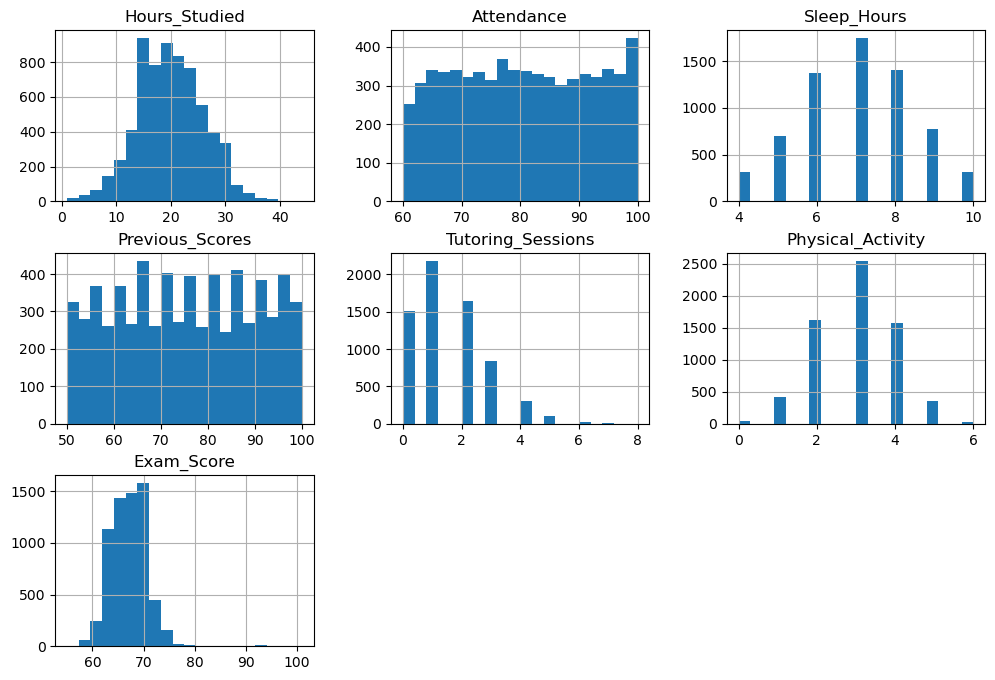

In [7]:
df.hist(bins=20, figsize=(12,8))
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, 
                                       random_state=42)

In [9]:
train_set.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
5810,27,79,Low,High,Yes,8,63,High,Yes,2,Low,Medium,Public,Negative,5,No,College,Moderate,Female,69
1268,16,86,High,Medium,Yes,7,94,Medium,Yes,2,Low,High,Public,Neutral,3,No,High School,Moderate,Female,69
414,22,87,Low,Medium,No,8,83,Low,Yes,1,Low,Medium,Public,Neutral,1,No,College,Far,Male,66
4745,18,100,High,Medium,Yes,10,86,Medium,Yes,1,Medium,Medium,Public,Neutral,3,No,High School,Near,Male,72
654,35,78,High,Low,Yes,10,99,Medium,Yes,1,Low,Medium,Private,Positive,2,No,High School,Near,Male,72


### Discovering and Visualizing Data

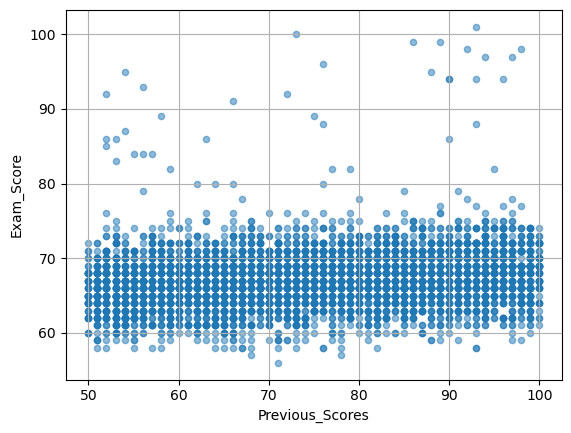

In [20]:
train_set.plot(kind="scatter", x="Previous_Scores", y="Exam_Score", grid=True, alpha=0.5)
plt.show()

Now let's see exam scores distributions per gender

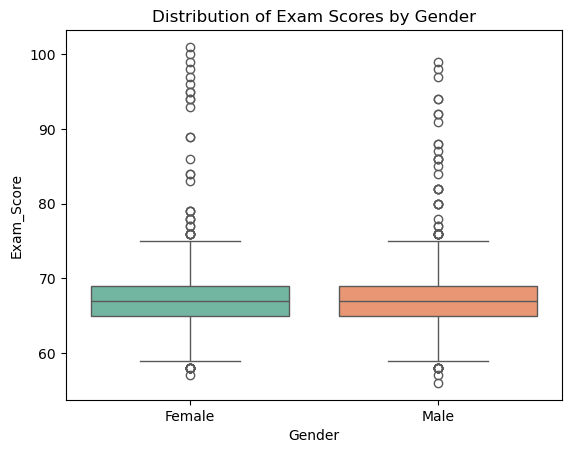

In [37]:
sns.boxplot(data=train_set, x="Gender", y="Exam_Score", hue="Gender", palette="Set2")
plt.title("Distribution of Exam Scores by Gender")
plt.show()

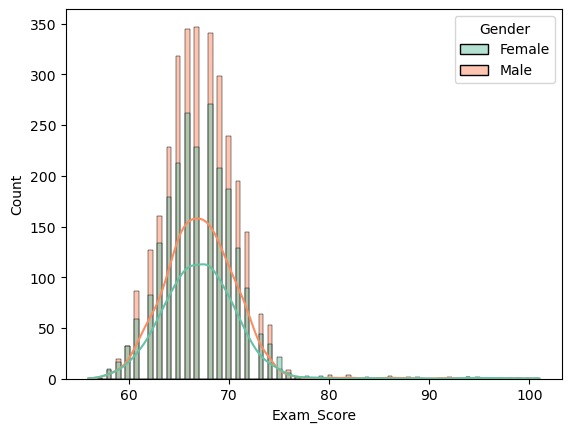

In [38]:
sns.histplot(data=train_set, x="Exam_Score", hue="Gender", kde=True, palette="Set2")
plt.show()

### Looking for correlations

In [40]:
corr_matrix = train_set.corr(numeric_only=True)

In [42]:
corr_matrix["Exam_Score"].sort_values(ascending=False)

Exam_Score           1.000000
Attendance           0.579000
Hours_Studied        0.436510
Previous_Scores      0.172939
Tutoring_Sessions    0.156122
Physical_Activity    0.035173
Sleep_Hours         -0.023253
Name: Exam_Score, dtype: float64

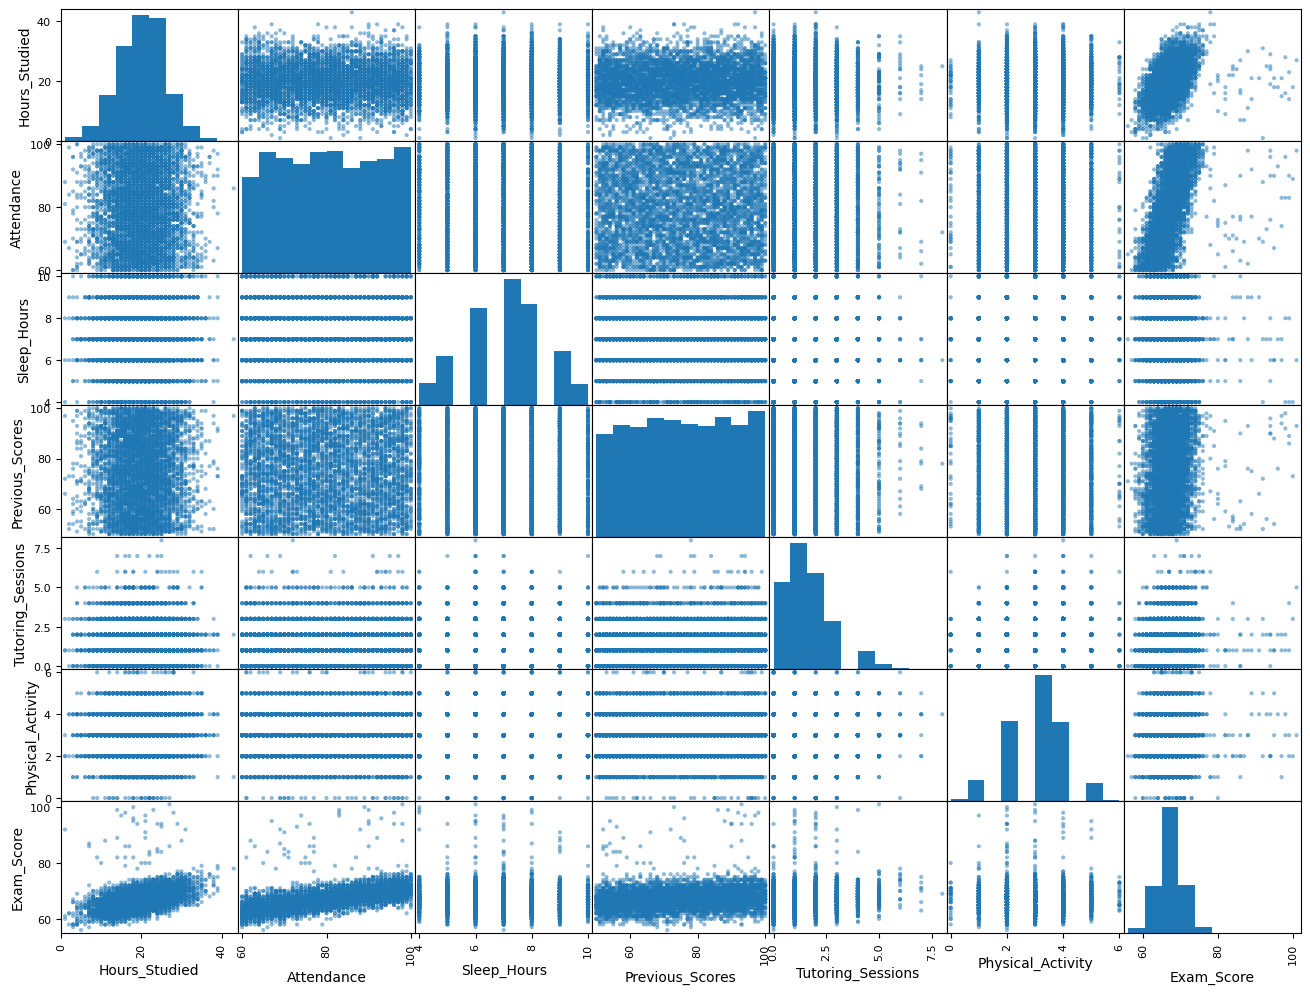

In [47]:
from pandas.plotting import scatter_matrix

scatter_matrix(train_set, figsize=(16, 12))
plt.show()

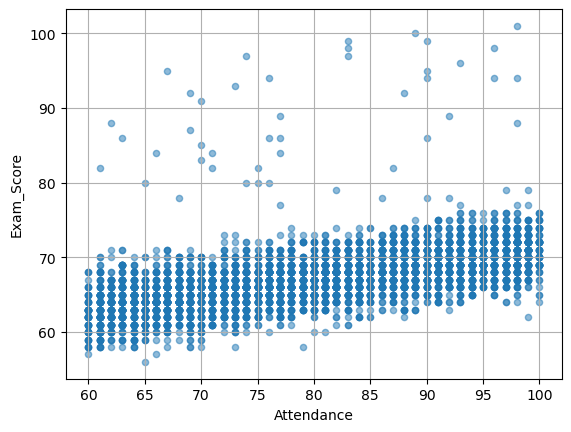

In [55]:
train_set.plot(kind="scatter", x="Attendance", y="Exam_Score", grid=True, alpha=0.5)
plt.show()

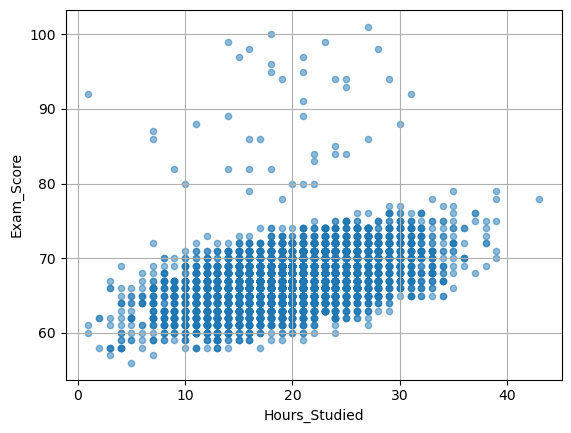

In [56]:
train_set.plot(kind="scatter", x="Hours_Studied", y="Exam_Score", grid=True, alpha=0.5)
plt.show()

In [ ]:
# Analyse categorical variables